In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as mticker

import os
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *


In [2]:

#fontsize = 15
kappa = 20
FrameTension="IsotropicFrameTension"
InitialConfiguration = "FromFlat"
N_k = 10



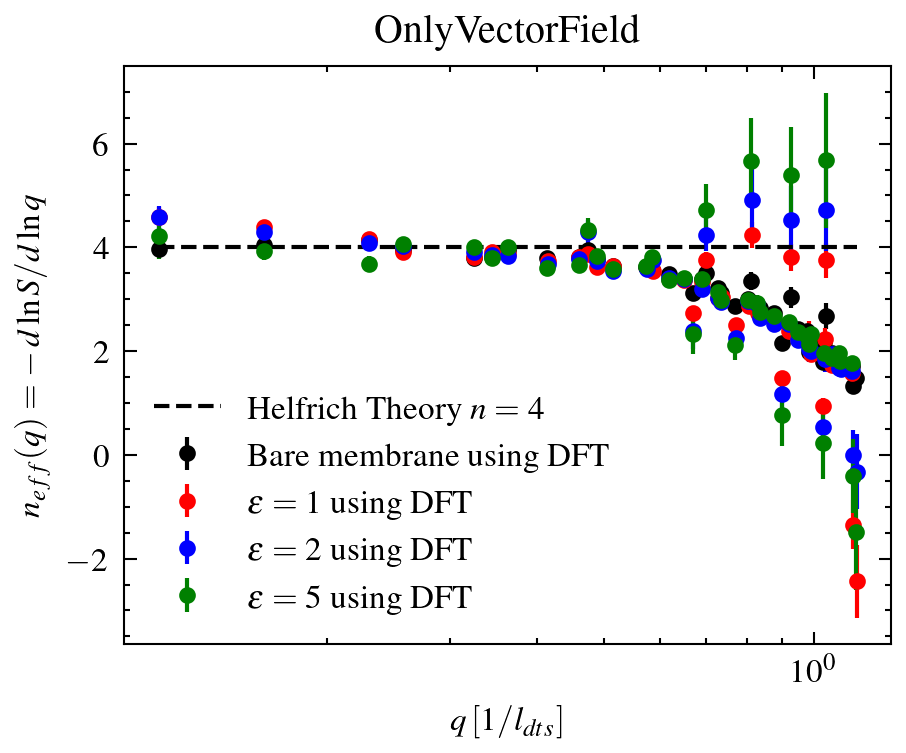

In [10]:
VFF="no"; KPKL_str="no"; XI_str="no"
FTMethod="DFT"

def n_eff_finite_diff(values):
    """Local effective exponent n_eff(q) = -d ln S / d ln q, computed per
    replica using that replica's own q (box size varies slightly per
    replica), then combined across replicas as mean +/- SEM."""
    q_arr, hqn_arr = values          # each (N_unique, N_r)
    log_q   = np.log(q_arr)
    log_hqn = np.log(hqn_arr)
    N_unique, N_r = hqn_arr.shape

    dSdq = np.empty((N_unique, N_r))
    dSdq[1:-1] = -(log_hqn[2:] - log_hqn[:-2]) / (log_q[2:] - log_q[:-2])
    dSdq[0]    = -(log_hqn[1]  - log_hqn[0])  / (log_q[1]  - log_q[0])
    dSdq[-1]   = -(log_hqn[-2] - log_hqn[-1]) / (log_q[-2] - log_q[-1])

    q_mean    = q_arr.mean(axis=1)
    n_eff     = dSdq.mean(axis=1)
    n_eff_err = dSdq.std(axis=1, ddof=1) / np.sqrt(N_r)
    return q_mean, n_eff, n_eff_err

fig, ax = plt.subplots()
q_all = []

Simulation = "OnlyMembrane"
EPS = "no"
AnalysisFile = f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
data = load_boxsize_fourier_file(AnalysisFile)
values = data[('q', '<u u>')]
q_mean, n_eff, n_eff_err = n_eff_finite_diff(values)
ax.errorbar(q_mean, n_eff, yerr=n_eff_err, fmt='.', label=rf"Bare membrane using {FTMethod}")
q_all.append(q_mean)

Simulation = "OnlyVectorField"
EPS_list = ["1","2","5"]
for EPS in EPS_list:
    AnalysisFile = f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
    data = load_boxsize_fourier_file(AnalysisFile)
    values = data[('q', '<u u>')]
    q_mean, n_eff, n_eff_err = n_eff_finite_diff(values)
    ax.errorbar(q_mean, n_eff, yerr=n_eff_err, fmt='.', label=rf"$\epsilon={EPS}$ using {FTMethod}")
    q_all.append(q_mean)

q_all = np.concatenate(q_all)


ax.hlines(4, q_all.min(), q_all.max(), linestyles='dashed', label=r"Helfrich Theory $n=4$")
ax.set_xscale('log')
ax.set_xlabel(r"$q\,[1/l_{dts}]$")
ax.set_ylabel(r"$n_{eff}(q) = -\,d\ln S / d\ln q$")
ax.set_title(Simulation)
ax.legend()
plt.show()

In [4]:
"""
Local effective-exponent (finite-difference) analysis of a membrane
undulation spectrum <|h_q|^2> ~ C q^-n.

Goal: instead of fitting a single global power law over an arbitrarily
chosen (j1, j2) window, compute the *local* slope

    n_eff(q) = - d ln S(q) / d ln q

as a function of q. If pure Helfrich bending holds, n_eff(q) should show
a genuine plateau at ~4 over some intermediate q-range, with deviations
at low q (poor statistics / few independent modes) and high q (mesh
discretization). The plateau boundaries then define a *physically
motivated* fitting window (j1, j2), rather than one chosen because it
happens to give n closest to 4.

Adjust the loading block at the top to match your actual data layout;
everything below only assumes you end up with:
    q          : 1D array of |q| bin centers
    mean_hq2   : 1D array, <|h_q|^2> per bin
    sem_hq2    : 1D array, standard error of the mean per bin
    n_samples  : 1D array, degeneracy g(q) per bin (# independent modes averaged)
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------
VFF = "no"; EPS = "no"; KPKL_str = "no"; XI_str = "no"; Simulation = "OnlyMembrane"

AnalysisFile = (
    f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}"
    f"/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
)
data = load_boxsize_fourier_file(AnalysisFile)

q = data[("q", "<u u>")][:, 0]      # |q| per radial bin
hqn = data[("q", "<u u>")][:, 1:]   # per-bin samples: individual |h_q|^2 values
                                     # for every q-vector (and/or every frame)
                                     # that falls in that |q| bin. Rows are
                                     # typically NaN-padded to a common width
                                     # since g(q) differs bin to bin.

# ---------------------------------------------------------------------
# 2. Reduce each bin to a mean, an uncertainty, and a degeneracy g(q)
# ---------------------------------------------------------------------
mask = ~np.isnan(hqn)
n_samples = mask.sum(axis=1)                     # g(q): independent modes per bin
mean_hq2  = np.nanmean(hqn, axis=1)
std_hq2   = np.nanstd(hqn, axis=1, ddof=1)
sem_hq2   = std_hq2 / np.sqrt(np.maximum(n_samples, 1))

# propagate the SEM into log space (delta method: sigma_lnS ~ sigma_S / S)
sigma_lnS = sem_hq2 / mean_hq2

lnq = np.log(q)
lnS = np.log(mean_hq2)

print(f"{len(q)} q-bins, degeneracy g(q) ranges {n_samples.min()}-{n_samples.max()}")

# ---------------------------------------------------------------------
# 3a. Plain adjacent-point finite difference (noisy, use only as a sanity check)
# ---------------------------------------------------------------------
n_eff_fwd = -np.diff(lnS) / np.diff(lnq)
q_fwd = np.sqrt(q[1:] * q[:-1])          # geometric mean = natural log-space midpoint

# ---------------------------------------------------------------------
# 3b. Centered finite difference (better than forward difference)
# ---------------------------------------------------------------------
n_eff_c = -(lnS[2:] - lnS[:-2]) / (lnq[2:] - lnq[:-2])
q_c = q[1:-1]

# ---------------------------------------------------------------------
# 3c. Windowed, weighted local linear regression (recommended)
#     Fits a local straight line to ln S vs ln q in a small sliding window,
#     weighted by 1/sigma_lnS^2 (i.e. by mode degeneracy/variance). This
#     smooths out point-to-point noise while still tracking real curvature,
#     and gives you an uncertainty on n_eff at each q.
# ---------------------------------------------------------------------
def local_weighted_slope(x, y, w, i, half_window):
    lo, hi = max(0, i - half_window), min(len(x), i + half_window + 1)
    xw, yw, ww = x[lo:hi], y[lo:hi], w[lo:hi]
    if len(xw) < 3:
        return np.nan, np.nan
    W = ww.sum()
    xbar = (ww * xw).sum() / W
    ybar = (ww * yw).sum() / W
    Sxx = (ww * (xw - xbar) ** 2).sum()
    Sxy = (ww * (xw - xbar) * (yw - ybar)).sum()
    slope = Sxy / Sxx
    dof = len(xw) - 2
    if dof <= 0:
        return slope, np.nan
    resid = yw - (ybar + slope * (xw - xbar))
    s2 = (ww * resid ** 2).sum() / dof
    slope_err = np.sqrt(s2 / Sxx)
    return slope, slope_err

half_window = 2  # tune: larger -> smoother but more biased across real curvature
weights = 1.0 / sigma_lnS ** 2

n_eff_win = np.full(len(q), np.nan)
n_eff_win_err = np.full(len(q), np.nan)
for i in range(len(q)):
    s, se = local_weighted_slope(lnq, lnS, weights, i, half_window)
    n_eff_win[i] = -s
    n_eff_win_err[i] = se

# ---------------------------------------------------------------------
# 4. Plot n_eff(q) to see the plateau
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(q, n_eff_win, yerr=n_eff_win_err, fmt="o-", ms=3, capsize=2,
            label=f"windowed WLS (half-window={half_window})")
ax.plot(q_c, n_eff_c, ".", alpha=0.35, label="centered finite diff (raw)")
ax.axhline(4, ls="--", c="k", lw=1, label="Helfrich n=4")
ax.set_xscale("log")
ax.set_xlabel(r"$q\,[1/d_0]$")
ax.set_ylabel(r"$n_{eff}(q) = -\,d\ln S / d\ln q$")
ax.legend()
fig.tight_layout()
fig.savefig("n_eff_vs_q.png", dpi=150)
plt.show()

# ---------------------------------------------------------------------
# 5. Auto-detect the plateau: longest contiguous run of q-bins whose
#    n_eff is within `tol` (in units of its own error bar) of 4.
# ---------------------------------------------------------------------
def find_plateau(n_eff, n_eff_err, target=4.0, tol=1.5):
    """Return (start_idx, end_idx) of the longest run where
    |n_eff - target| <= tol * n_eff_err."""
    good = np.abs(n_eff - target) <= tol * np.nan_to_num(n_eff_err, nan=np.inf)
    best = (0, 0)
    start = None
    for i, g in enumerate(good):
        if g and start is None:
            start = i
        if (not g or i == len(good) - 1) and start is not None:
            end = i if not g else i + 1
            if end - start > best[1] - best[0]:
                best = (start, end)
            start = None
    return best

j1, j2 = find_plateau(n_eff_win, n_eff_win_err)
print(f"Detected plateau: bins [{j1}, {j2}) -> q in [{q[j1]:.4f}, {q[j2-1]:.4f}]")

# ---------------------------------------------------------------------
# 6. Final global fit, restricted to the detected plateau, weighted by
#    the same 1/sigma_lnS^2 used above -- this is your rigorous n and
#    its uncertainty, chosen by the shape of the data, not by proximity
#    to n=4.
# ---------------------------------------------------------------------
sel = slice(j1, j2)
w_fit = weights[sel]
X = lnq[sel]
Y = lnS[sel]
W = w_fit.sum()
xbar = (w_fit * X).sum() / W
ybar = (w_fit * Y).sum() / W
Sxx = (w_fit * (X - xbar) ** 2).sum()
Sxy = (w_fit * (X - xbar) * (Y - ybar)).sum()
slope = Sxy / Sxx
dof = len(X) - 2
resid = Y - (ybar + slope * (X - xbar))
s2 = (w_fit * resid ** 2).sum() / dof
slope_err = np.sqrt(s2 / Sxx)

n_fit = -slope
n_fit_err = slope_err
print(f"Weighted power-law fit on plateau: n = {n_fit:.3f} +/- {n_fit_err:.3f}")

TypeError: tuple indices must be integers or slices, not tuple